# RECON evaporation shed

Script to retrieve and plot the reconciled moisture flow of evaporation at the source falling as rainfall 
in downwind locations based on NetCDF moisture flow data (RECON).  

This notebook aggregates the evaporation shed from every RECON source grid cell whose center falls inside a polygon.
Set `polygon_file` to a WGS84 or CRS-tagged ESRI shapefile. The output is the precipitation flows in downwind target cells that contribute to annual evaporation within that polygon.

Created by Elena De Petrillo (elena.depetrillo@polito.it) & Luca Monaco (luca.monaco@cimafoundation.org)  
Modified by Romain Thomas (contact@romainthomas.net)
2025

Repurposed for Kansas and altered for polygon inputs and mapping by Sam Zipper (samzipper@ku.edu)

## Imports

In [35]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
from matplotlib.path import Path as MatplotlibPath
from pathlib import Path
import shapefile
from pyproj import CRS, Transformer

## Variables

In [36]:
home = Path.home()
current_dir = Path.cwd()
repository_root = current_dir if (current_dir / "data").exists() else current_dir.parent

# Set the path where the dataset is stored
input_file = home / "OneDrive - University of Kansas" / "Research" / "MoistureRecycling" / "RECON" / "RECON_moisture_flows_0.5.nc"
precipitation_volume_file = home / "OneDrive - University of Kansas" / "Research" / "MoistureRecycling" / "RECON" / "RECON_ERA5_avgYear_0.5_volumes.nc"
# Set the path where you want to save the plot
output_map_plot_path = "evaporation_shed_map.png"

# Set the polygon that defines the evaporation source area. The example
# shapefile is in geographic coordinates; any CRS is supported when its .prj
# sidecar file is present. All polygon features are included.
polygon_file = repository_root / "data" / "HPA_extent.shp"

# Constants for calculation
ymax = 122079329.40990189  # Maximum moisture flow value
ymin = 10**-3  # Minimum moisture flow value

# Longitude/latitude bounds for the output map (west, east, south, north).
map_bounds = (-130, -60, 15, 60)

## Data processing

### Load dataset

In [37]:
dataset = xr.open_dataset(input_file)
precipitation_volumes = xr.open_dataset(precipitation_volume_file)

### Select source cells inside the polygon

A source cell is included when its center lies inside the polygon. Polygon holes are excluded.

In [38]:
polygon_file = Path(polygon_file)
if polygon_file.suffix.lower() != ".shp":
    raise ValueError("polygon_file must be an ESRI shapefile (.shp).")
if not polygon_file.exists():
    raise FileNotFoundError(f"Polygon file not found: {polygon_file}")

prj_file = polygon_file.with_suffix(".prj")
if not prj_file.exists():
    raise FileNotFoundError(f"Polygon CRS file not found: {prj_file}")

transformer = Transformer.from_crs(
    CRS.from_wkt(prj_file.read_text()), CRS.from_epsg(4326), always_xy=True
)
polygon_rings = []
for shape in shapefile.Reader(str(polygon_file)).shapes():
    if not shape.points:
        continue
    part_starts = list(shape.parts) + [len(shape.points)]
    for start, end in zip(part_starts[:-1], part_starts[1:]):
        x, y = np.asarray(shape.points[start:end]).T
        longitude, latitude = transformer.transform(x, y)
        polygon_rings.append(np.column_stack((longitude, latitude)))

if not polygon_rings:
    raise ValueError(f"No polygon geometry found in {polygon_file}")

source_lats = dataset.sourcelat.values
source_lons = dataset.sourcelon.values
source_lons_wgs84 = (source_lons + 180) % 360 - 180
source_lon_grid, source_lat_grid = np.meshgrid(source_lons_wgs84, source_lats)
source_points = np.column_stack((source_lon_grid.ravel(), source_lat_grid.ravel()))

# Even-odd containment handles both exterior rings and interior holes.
inside_polygon = np.zeros(source_points.shape[0], dtype=bool)
for ring in polygon_rings:
    inside_polygon ^= MatplotlibPath(ring).contains_points(source_points)

source_mask = xr.DataArray(
    inside_polygon.reshape(source_lat_grid.shape),
    coords={"sourcelat": source_lats, "sourcelon": source_lons},
    dims=("sourcelat", "sourcelon"),
)
selected_cell_count = int(source_mask.sum())
if selected_cell_count == 0:
    raise ValueError("The polygon does not contain any RECON source-cell centers.")

source_lat_indices, source_lon_indices = np.nonzero(source_mask.values)
print(f"Selected {selected_cell_count} RECON source cells from {polygon_file.name}.")

Selected 194 RECON source cells from HPA_extent.shp.


### Convert to cubic meters and calculate the sink-cell percentage

In [39]:
# Decode each source-to-target flow before aggregating; encoded values are
# logarithmic and therefore must not be summed directly. Process source
# cells in batches so even large source selections do not create a 4-D array.
batch_size = 32
moisture_flow = dataset["moisture_flow"]

def aggregate_source_flows(source_lat_indices, source_lon_indices, description):
    source_count = len(source_lat_indices)
    aggregated_flow = None
    batch_count = (source_count + batch_size - 1) // batch_size
    for batch_number, batch_start in enumerate(range(0, source_count, batch_size), start=1):
        batch_stop = min(batch_start + batch_size, source_count)
        evaporation_shed_raw = moisture_flow.isel(
            sourcelat=xr.DataArray(source_lat_indices[batch_start:batch_stop], dims="source_cell"),
            sourcelon=xr.DataArray(source_lon_indices[batch_start:batch_stop], dims="source_cell"),
        )
        batch_flow = xr.where(
            evaporation_shed_raw == 0,
            0,
            10 ** (
                ((evaporation_shed_raw - 1) / 254) * (np.log10(ymax) - np.log10(ymin))
                + np.log10(ymin)
            ),
        ).sum(dim="source_cell", skipna=True)
        aggregated_flow = batch_flow if aggregated_flow is None else aggregated_flow + batch_flow
        if batch_count > 1 and (batch_number % 100 == 0 or batch_number == batch_count):
            print(f"{description}: batch {batch_number:,} of {batch_count:,}")
    return aggregated_flow.transpose("targetlat", "targetlon")

evaporation_shed = aggregate_source_flows(
    source_lat_indices, source_lon_indices, "Polygon aggregation"
)
# ERA5_TP_averageyear is reconciled annual precipitation in cubic meters
# on the same target grid, avoiding an expensive global source aggregation.
total_sink_precipitation = precipitation_volumes["ERA5_TP_averageyear"].rename(
    {"lat": "targetlat", "lon": "targetlon"}
).sel(
    targetlat=evaporation_shed.targetlat,
    targetlon=evaporation_shed.targetlon,
)
evaporation_percentage = xr.where(
    total_sink_precipitation > 0,
    evaporation_shed / total_sink_precipitation * 100,
    np.nan,
)

Polygon aggregation: batch 7 of 7


## Plot results

Plot saved at evaporation_shed_map.png


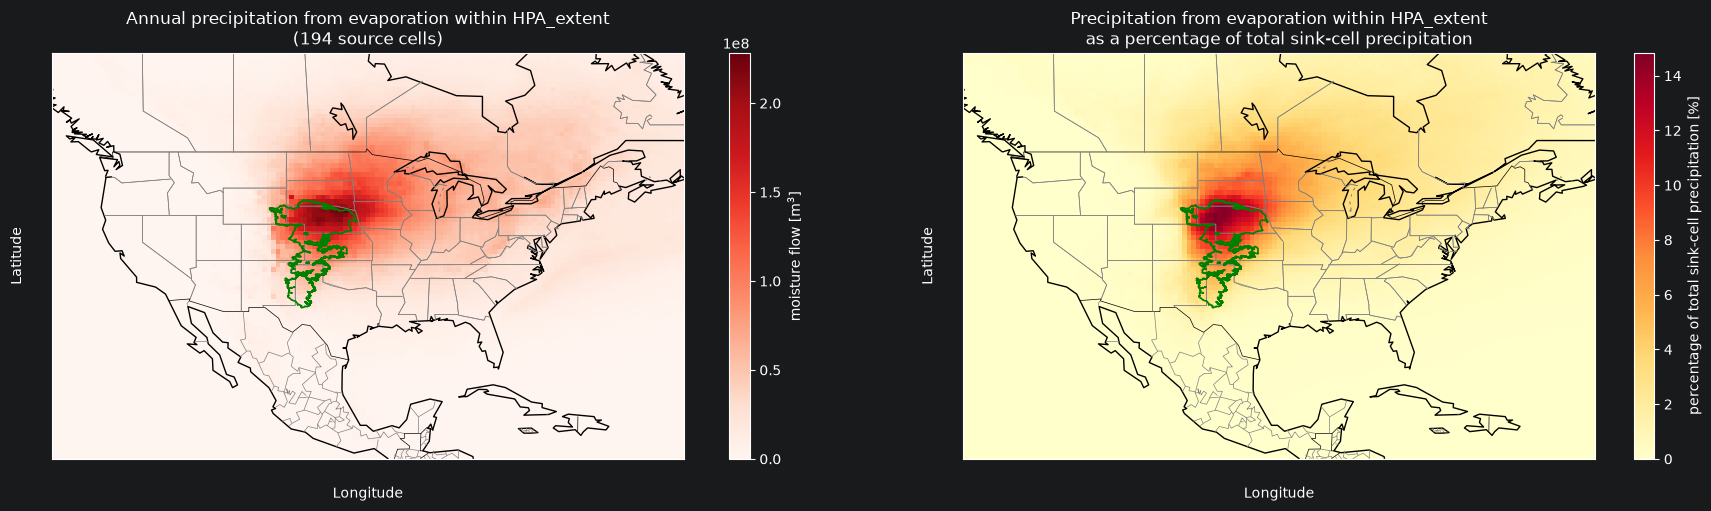

In [40]:
target_lats = evaporation_shed.targetlat.values
target_lons = (evaporation_shed.targetlon.values + 180) % 360 - 180
longitude_order = np.argsort(target_lons)
target_lons = target_lons[longitude_order]
shed_for_plot = evaporation_shed.isel(targetlon=longitude_order).values
percentage_for_plot = evaporation_percentage.isel(targetlon=longitude_order).values
percentage_max = float(np.nanmax(percentage_for_plot))
if not np.isfinite(percentage_max) or percentage_max <= 0:
    raise ValueError("No positive sink-cell percentages are available to plot.")
lon2d, lat2d = np.meshgrid(target_lons, target_lats)

def plot_shed_panel(ax, values, cmap, colorbar_label, title, mask_zeros=False, vmax=None):
    if mask_zeros:
        values = np.ma.masked_where(values == 0, values)
    else:
        values = np.ma.masked_invalid(values)
    cmap = plt.get_cmap(cmap).copy()
    cmap.set_bad(color="white")
    map_panel = Basemap(
        projection="cyl",
        llcrnrlat=map_bounds[2], urcrnrlat=map_bounds[3],
        llcrnrlon=map_bounds[0], urcrnrlon=map_bounds[1],
        resolution="c",
        ax=ax,
    )
    x, y = map_panel(lon2d, lat2d)
    plotted_values = map_panel.pcolormesh(
        x, y, values, cmap=cmap, shading="auto", vmin=0, vmax=vmax
    )
    map_panel.drawcoastlines()
    map_panel.drawcountries(color="black")
    map_panel.drawstates(color="0.5")
    for ring in polygon_rings:
        x_ring, y_ring = map_panel(ring[:, 0], ring[:, 1])
        map_panel.plot(x_ring, y_ring, color="green", linewidth=1.2)
    ax.set_title(title)
    ax.set_xlabel("Longitude", labelpad=20)
    ax.set_ylabel("Latitude", labelpad=20)
    fig.colorbar(plotted_values, ax=ax, label=colorbar_label)

fig, axes = plt.subplots(1, 2, figsize=(18, 5), constrained_layout=True)
plot_shed_panel(
    axes[0],
    shed_for_plot,
    "Reds",
    "moisture flow [m$^3$]",
    f"Annual precipitation from evaporation within {polygon_file.stem}\n"
    f"({selected_cell_count} source cells)",
    mask_zeros=True,
)
plot_shed_panel(
    axes[1],
    percentage_for_plot,
    "YlOrRd",
    "percentage of total sink-cell precipitation [%]",
    f"Precipitation from evaporation within {polygon_file.stem}\n"
    "as a percentage of total sink-cell precipitation",
    vmax=percentage_max,
)
fig.savefig(output_map_plot_path, dpi=200, bbox_inches="tight")
print(f"Plot saved at {output_map_plot_path}")
plt.show()